Phong Model


In [52]:
import json
import os

import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms


def split_dataset(split_ration, dataset_path):
    train_ratio, val_ratio, _ = split_ration
    total_size = len(os.listdir(os.path.join(dataset_path, "images")))
    indices = list(range(total_size))

    train_end = int(total_size * train_ratio)
    val_end = train_end + int(total_size * val_ratio)

    train_indices = indices[:train_end]
    val_indices = indices[train_end:val_end]
    test_indices = indices[val_end:]

    return train_indices, val_indices, test_indices

MIN_VALS = [
    -25.0, -25.0, -35.0,    # Obiekt (X-5, Y-5, Z-15)
    0.0, 0.0, 0.0,          # Kolor (0-1)
    3.0,                    # Shininess (3-20)
    -25.0, -25.0, -35.0     # Światło (X-5, Y-5, Z-15)
]

MAX_VALS= [
    15.0, 15.0, 5.0,        # Obiekt (X-5, Y-5, Z-15)
    1.0, 1.0, 1.0,          # Kolor (0-1)
    20.0,                   # Shininess (3-20)
    15.0, 15.0, 5.0         # Światło (X-5, Y-5, Z-15)
]

class PhongDataset(Dataset):
    def __init__(
        self,
        base_path,
        indices,
    ) -> None:
        self.image_path = os.path.join(base_path, "images")
        self.json_path = os.path.join(base_path, "params.json")
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        with open(self.json_path, "r") as f:
            all_samples = json.load(f)

        self.samples = [all_samples[i] for i in indices]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        input_vec = (
            sample["model_translation_relative"]
            + sample["material_diffuse"]
            + [sample["material_shininess"]]
            + sample["light_position_relative"]
        )
        input_tensor = torch.tensor(input_vec, dtype=torch.float32)
        min_vals = torch.tensor(MIN_VALS, dtype=torch.float32)
        max_vals = torch.tensor(MAX_VALS, dtype=torch.float32)
        ranges = max_vals - min_vals
        ranges[ranges == 0] = 1.0
        normalized_input = 2 * (input_tensor - min_vals) / ranges - 1

        image = Image.open(
            os.path.join(self.image_path, sample["image_filename"])
        ).convert("RGB")
        target_tensor = self.transform(image)

        return normalized_input, target_tensor

In [2]:
!pwd
# delete old repo
!rm sigk -r
# clone new version of repo, main branch
!git clone -b main https://github.com/kraszor/SIGK-2025Z.git

/content
rm: cannot remove 'sigk': No such file or directory
Cloning into 'SIGK-2025Z'...
remote: Enumerating objects: 3235, done.
remote: Counting objects: 100% (3235/3235), done.
remote: Compressing objects: 100% (3184/3184), done.
remote: Total 3235 (delta 107), reused 3126 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (3235/3235), 82.28 MiB | 15.69 MiB/s, done.
Resolving deltas: 100% (107/107), done.


Load datasets

In [68]:
from torch.utils.data import DataLoader
base_path = "/content/SIGK-2025Z/neural_rendering/output"
split_ratio = [0.6, 0.2, 0.2]
train_indices, val_indices, test_indices = split_dataset(split_ratio, base_path)
train_set = PhongDataset(base_path, train_indices)
val_set = PhongDataset(base_path, val_indices)
test_set = PhongDataset(base_path, test_indices)

batch_size = 16
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

In [54]:
train_set[0]

(tensor([-0.4500,  0.3500, -0.4000,  0.0588,  0.1216,  0.4275, -0.1765, -0.0500,
         -0.6500, -0.0500]),
 tensor([[[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.]],
 
         [[-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          ...,
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1.,  ..., -1., -1., -1.],
          [-1., -1., -1

Phong model

In [67]:
import torch
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, input_dim: int = 10, output_shape: tuple = (3, 128, 128)):
        super().__init__()
        self.output_shape = output_shape
        self.latent_size = 4

        self.fc = nn.Sequential(
            nn.Linear(input_dim, 512 * self.latent_size * self.latent_size),
            nn.ReLU()
        )

        self.upsample = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.ConvTranspose2d(64, 32, 4, 2, 1, bias=False),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.ConvTranspose2d(32, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        x = x.view(-1, 512, self.latent_size, self.latent_size)
        return self.upsample(x)

class Discriminator(nn.Module):
    def __init__(self, input_channels: int = 3, condition_dim: int = 10):
        super().__init__()
        total_input_channels = input_channels + condition_dim
        self.model = nn.Sequential(
            nn.Conv2d(total_input_channels, 64, 4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 512, 4, stride=2, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Conv2d(512, 1024, 4, stride=2, padding=1),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(1024 * 4 * 4, 1),
            nn.Sigmoid()
        )

    def forward(self, image, condition_vec) -> torch.Tensor:
        condition_vec = condition_vec.view(condition_vec.size(0), condition_vec.size(1), 1, 1)

        condition_vec = condition_vec.repeat(1, 1, image.size(2), image.size(3))

        x = torch.cat([image, condition_vec], dim=1)

        return self.model(x)

Train phong model

Generator

In [69]:
import time

def validate(model, validation_loader, criterion, device, epoch=None):
    model.eval()
    total_loss = 0
    batch_count = 0
    start_time = time.time()

    with torch.no_grad():
        for input_image, target_image in validation_loader:
            input_image, target_image = input_image.to(device), target_image.to(device)

            output_image = model(input_image)
            loss = criterion(output_image, target_image)

            total_loss += loss.item()
            batch_count += 1

    avg_loss = total_loss / len(validation_loader)
    val_time = time.time() - start_time
    print(f"Epoch {epoch} Validation - Loss: {avg_loss:.6f}, "
                   f"Time: {val_time:.2f}s")

    return avg_loss

def warmup_generator(
    generator,
    train_dataloader,
    val_dataloader,
    criterion,
    optimizer,
    device,
    epochs,
    lambda_l1: float = 100.0
):
    print("START")
    for epoch in range(epochs):
        epoch_loss = 0

        for input_image, target_image in train_dataloader:
            input_image, target_image = input_image.to(device), target_image.to(device)

            optimizer.zero_grad()

            output_image = generator(input_image)
            l1 = criterion(output_image, target_image)
            loss_G = l1 * lambda_l1
            # print(f"{l1=} -> {loss_G}")
            loss_G.backward()
            optimizer.step()

            epoch_loss += loss_G.item()

        val_loss = validate(generator, val_dataloader, nn.L1Loss(), device, epoch)

        epoch_loss = epoch_loss/len(train_dataloader)
        print(f"Epoch {epoch + 1} Summary:")
        print(f"  Train Loss: {loss_G/len(train_loader):.4f}")
        print(f"  Val Loss: {val_loss/len(train_loader):.4f}")

        print("-" * 40)

    print("="*80)
    print("TRAINING COMPLETED")

    return generator



def train_gan(
  generator,
  discriminator,
  generator_optimizer,
  discriminator_optimizer,
  adversarial_loss,
  train_loader,
  val_loader,
  device,
  epochs: int = 20,
  lambda_l1: float = 100.0
):
  generator = generator.to(device)
  discriminator = discriminator.to(device)
  l1_loss = nn.L1Loss()

  print("START")
  patience = 10
  best_val_loss = float("inf")
  epochs_without_improvement = 0

  for epoch in range(epochs):
    generator.train()
    discriminator.train()
    G_loss_total = 0
    D_loss_total = 0

    for input_image, target_image in train_loader:
      input_image, target_image = input_image.to(device), target_image.to(device)
      batch_size = target_image.size(0)
      real_labels = torch.ones(input_image.size(0), 1).to(device) * 0.9
      fake_labels = torch.zeros(input_image.size(0), 1).to(device) + 0.1

      discriminator_optimizer.zero_grad()
      with torch.no_grad():
          fake_images = generator(input_image)

      real_prediction = discriminator(target_image, input_image)
      real_loss_D = adversarial_loss(real_prediction, real_labels)

      fake_prediction = discriminator(fake_images.detach(), input_image)
      fake_loss_D = adversarial_loss(fake_prediction, fake_labels)

      loss_D = (real_loss_D + fake_loss_D) / 2
      loss_D.backward()
      discriminator_optimizer.step()

      generator_optimizer.zero_grad()
      fake_images = generator(input_image)
      fake_G = discriminator(fake_images, input_image)

      loss_G_adv = adversarial_loss(fake_G, real_labels)
      loss_G_l1 = l1_loss(fake_images, target_image)

      loss_G = loss_G_adv + lambda_l1 * loss_G_l1
      print(f"{loss_G_adv=} -> {lambda_l1 * loss_G_l1}")
      loss_G.backward()
      generator_optimizer.step()

      G_loss_total += loss_G.item()
      D_loss_total += loss_D.item()

    val_loss = validate(generator, val_loader, l1_loss, device, epoch)

    print(f"Epoch {epoch + 1} Summary:")
    print(f"  Generator Loss: {G_loss_total/len(train_loader):.4f}")
    print(f"  Discriminator Loss: {D_loss_total/len(train_loader):.4f}")

    print(f"  Validation Loss: {val_loss:.6f}")

    if val_loss < best_val_loss:
      improvement = best_val_loss - val_loss
      best_val_loss = val_loss
      epochs_without_improvement = 0
      model_filename = f"best_model"
      model_filename += ".pth"
      torch.save(generator.state_dict(), model_filename)
      print(f"  *** NEW BEST MODEL! Improvement: {improvement:.6f}")
      print(f"  Saved as: {model_filename}")

    else:
        epochs_without_improvement += 1
        print(f"  No improvement (best: {best_val_loss:.6f})")
        print(f"  Epochs without improvement: {epochs_without_improvement}/{patience}")

    # Early stopping check
    if epochs_without_improvement >= patience:
        print("="*80)
        print(f"EARLY STOPPING triggered after {epoch + 1} epochs")
        print(f"No improvement for {patience} consecutive epochs")
        print(f"Best validation loss: {best_val_loss:.6f}")
        print("="*80)
        break

    print("-" * 40)


In [27]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
# train Gan
load_model = False

generator = Generator()
discriminator = Discriminator()
generator = generator.to(device)
discriminator = discriminator.to(device)

if not load_model:
  try:

    lr_G = 0.0002
    lr_D = 0.00002
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.999))
    train_epochs=20
    warm_up_epochs = 7
    lambda_l1=5

    adversarial_loss = nn.BCELoss()

    torch.cuda.empty_cache()
    # Warm up generator
    print("WARM UP GENERATOR")
    generator = warmup_generator(generator, train_loader, val_loader, nn.L1Loss(), optimizer_G, device, warm_up_epochs, lambda_l1)
    print("#"*40)
    print("TRAIN GAN")
    train_gan(generator, discriminator, optimizer_G, optimizer_D, adversarial_loss, train_loader, val_loader, device, train_epochs, lambda_l1)

  finally:
    BEST_LOCAL_PATH = 'best_model.pth'
    best_state_dict = torch.load(BEST_LOCAL_PATH, map_location=device)

    generator.load_state_dict(best_state_dict)
    print(f"Loaded best model parameters from {BEST_LOCAL_PATH}")

    SAVE_DIR = "/content/drive/MyDrive/SIGK/NeuralRendering/models"
    MODEL_FILENAME = 'best_generator.pth'
    SAVE_PATH = os.path.join(SAVE_DIR, MODEL_FILENAME)
    torch.save(generator.state_dict(), SAVE_PATH)
    print(f"Final best model state saved to {SAVE_PATH}")

else:
    print("LOADING MODEL")
    LOAD_PATH = '/content/drive/MyDrive/SIGK/NeuralRendering/models/best_generator.pth'
    state_dict = torch.load(LOAD_PATH, map_location=device)
    generator.load_state_dict(state_dict)




WARM UP GENERATOR
START
Epoch 0 Validation - Loss: 0.535019, Time: 0.65s
Epoch 1 Summary:
  Train Loss: 0.0240
  Val Loss: 0.0047
----------------------------------------
Epoch 1 Validation - Loss: 0.004485, Time: 0.65s
Epoch 2 Summary:
  Train Loss: 0.0002
  Val Loss: 0.0000
----------------------------------------
Epoch 2 Validation - Loss: 0.004031, Time: 0.82s
Epoch 3 Summary:
  Train Loss: 0.0002
  Val Loss: 0.0000
----------------------------------------
Epoch 3 Validation - Loss: 0.003918, Time: 0.65s
Epoch 4 Summary:
  Train Loss: 0.0002
  Val Loss: 0.0000
----------------------------------------
Epoch 4 Validation - Loss: 0.003868, Time: 0.65s
Epoch 5 Summary:
  Train Loss: 0.0001
  Val Loss: 0.0000
----------------------------------------
Epoch 5 Validation - Loss: 0.003841, Time: 0.67s
Epoch 6 Summary:
  Train Loss: 0.0001
  Val Loss: 0.0000
----------------------------------------
Epoch 6 Validation - Loss: 0.003823, Time: 0.79s
Epoch 7 Summary:
  Train Loss: 0.0002
  Val L

RuntimeError: Parent directory /content/drive/MyDrive/SIGK/NeuralRendering/models does not exist.

In [ ]:
# @title
# train Gan
load_model = False

generator = Generator()
discriminator = Discriminator()
generator = generator.to(device)
discriminator = discriminator.to(device)

if not load_model:
  try:

    lr_G = 0.0002
    lr_D = 0.0002
    optimizer_G = optim.Adam(generator.parameters(), lr=lr_G, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(discriminator.parameters(), lr=lr_D, betas=(0.5, 0.999))
    train_epochs=50
    warm_up_epochs = 5
    lambda_l1=100

    adversarial_loss = nn.BCELoss()

    torch.cuda.empty_cache()
    # Warm up generator
    print("WARM UP GENERATOR")
    generator = warmup_generator(generator, train_loader, val_loader, nn.L1Loss(), optimizer_G, device, warm_up_epochs, lambda_l1)
    print("#"*40)
    print("TRAIN GAN")
    train_gan(generator, discriminator, optimizer_G, optimizer_D, adversarial_loss, train_loader, val_loader, device, train_epochs, lambda_l1)

  finally:
    BEST_LOCAL_PATH = 'best_model.pth'
    best_state_dict = torch.load(BEST_LOCAL_PATH, map_location=device)

    generator.load_state_dict(best_state_dict)
    print(f"Loaded best model parameters from {BEST_LOCAL_PATH}")

    SAVE_DIR = "/content/drive/MyDrive/SIGK/NeuralRendering/models"
    MODEL_FILENAME = 'best_generator.pth'
    SAVE_PATH = os.path.join(SAVE_DIR, MODEL_FILENAME)
    torch.save(generator.state_dict(), SAVE_PATH)
    print(f"Final best model state saved to {SAVE_PATH}")

else:
    print("LOADING MODEL")
    LOAD_PATH = '/content/drive/MyDrive/SIGK/NeuralRendering/models/best_generator.pth'
    state_dict = torch.load(LOAD_PATH, map_location=device)
    generator.load_state_dict(state_dict)




WARM UP GENERATOR
START
Epoch 0 Validation - Loss: 0.388087, Time: 0.55s
Epoch 1 Summary:
  Train Loss: 43.056759
  Val Loss: 0.388087
----------------------------------------
Epoch 1 Validation - Loss: 0.003799, Time: 0.58s
Epoch 2 Summary:
  Train Loss: 0.327536
  Val Loss: 0.003799
----------------------------------------
Epoch 2 Validation - Loss: 0.003791, Time: 0.58s
Epoch 3 Summary:
  Train Loss: 0.543006
  Val Loss: 0.003791
----------------------------------------
Epoch 3 Validation - Loss: 0.003790, Time: 0.56s
Epoch 4 Summary:
  Train Loss: 0.388294
  Val Loss: 0.003790
----------------------------------------
Epoch 4 Validation - Loss: 0.003790, Time: 0.58s
Epoch 5 Summary:
  Train Loss: 0.245368
  Val Loss: 0.003790
----------------------------------------
TRAINING COMPLETED
########################################
TRAIN GAN
START
Epoch 0 Validation - Loss: 0.912715, Time: 0.56s
Epoch 1 Summary:
  Generator Loss: 107.0359
  Discriminator Loss: 0.3396
  Validation Loss: 0.9

KeyboardInterrupt: 

Visualize model

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def compare_images(generated, groundTruth, n=4):
    generated = generated.permute(0, 2, 3, 1).cpu().numpy()
    groundTruth    = groundTruth.permute(0, 2, 3, 1).cpu().numpy()

    k = min(n, len(generated), len(groundTruth))
    for i in range(k):
        fig, axes = plt.subplots(1, 2, figsize=(12, 2))

        generated[i] = (generated[i]+1.0)/2
        axes[0].imshow((generated[i].clip(0, 1)))
        axes[0].set_title("Generated")
        axes[0].axis("off")

        groundTruth[i] = (groundTruth[i]+1.0)/2
        axes[1].imshow(groundTruth[i].clip(0, 1).squeeze())
        axes[1].set_title("Ground Truth")
        axes[1].axis("off")


        plt.tight_layout()
        plt.show()


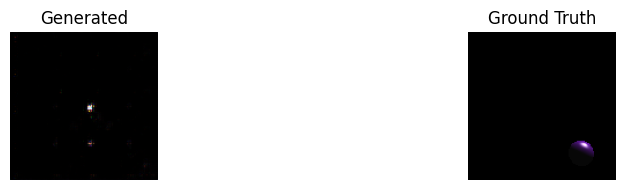

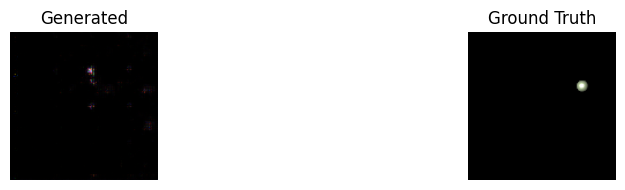

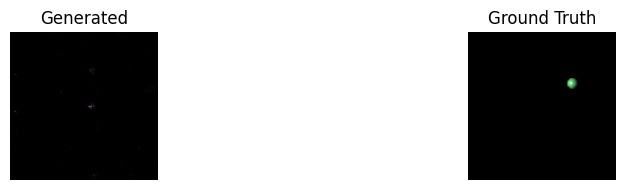

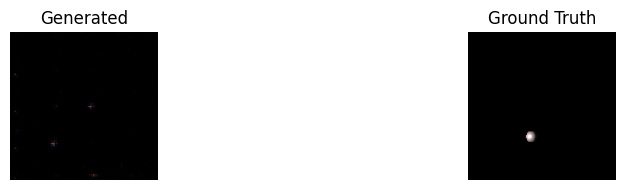

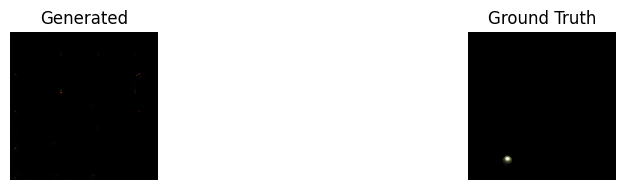

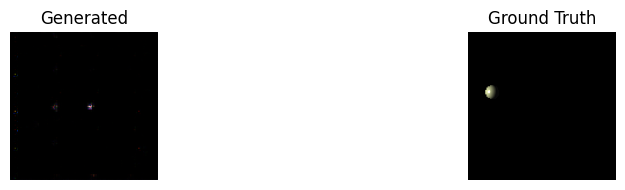

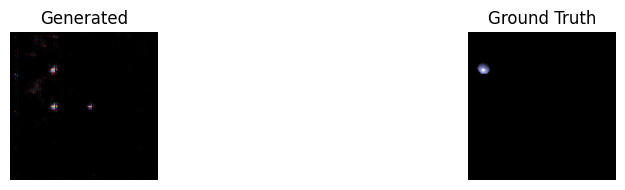

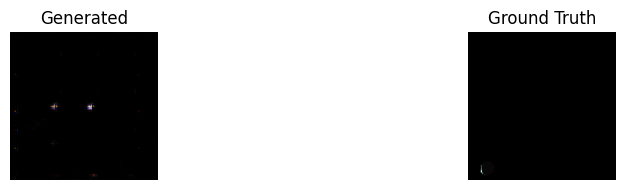

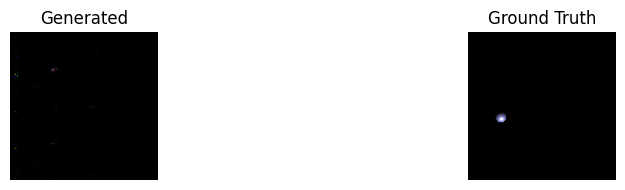

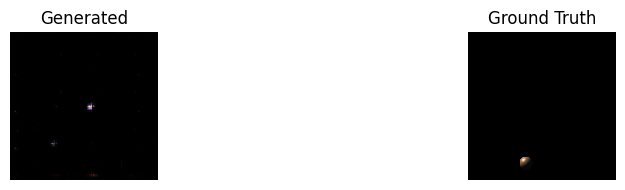

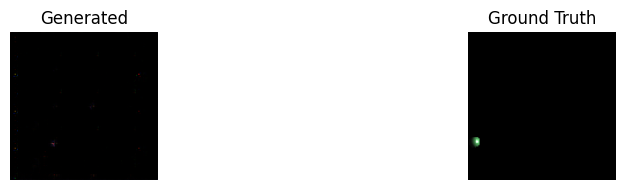

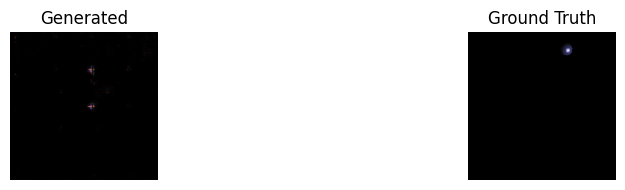

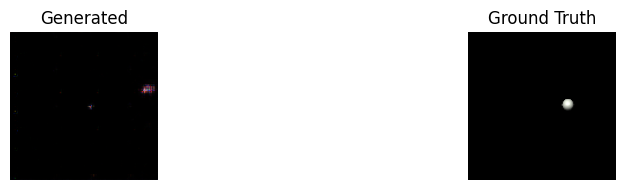

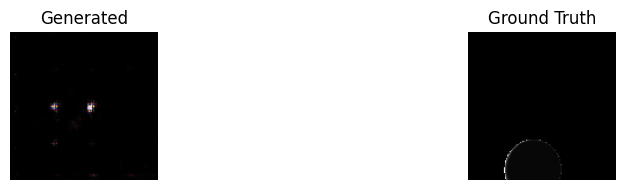

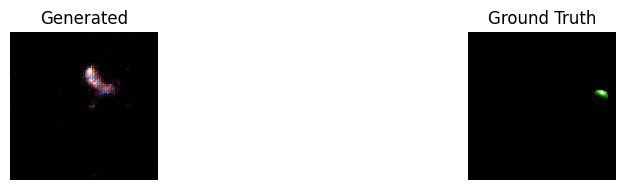

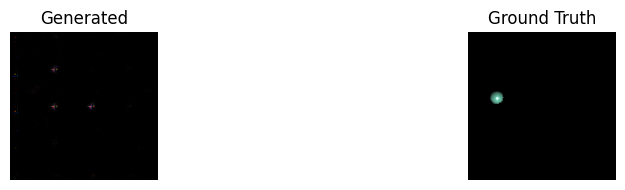

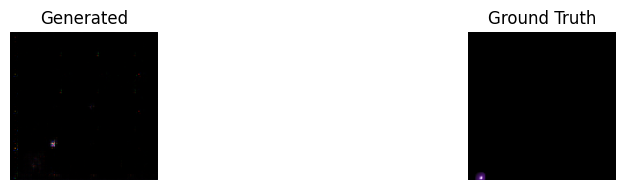

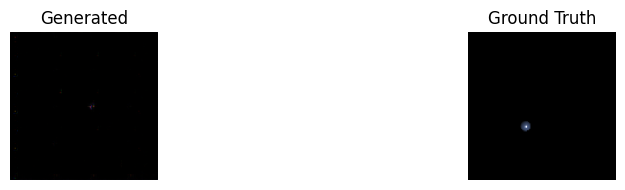

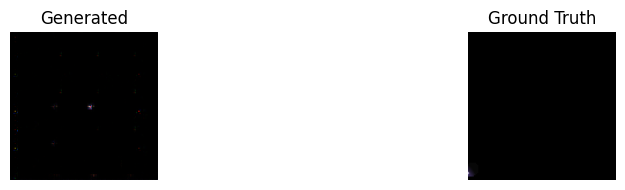

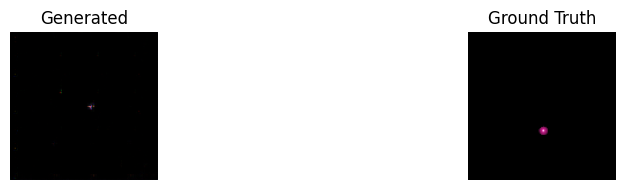

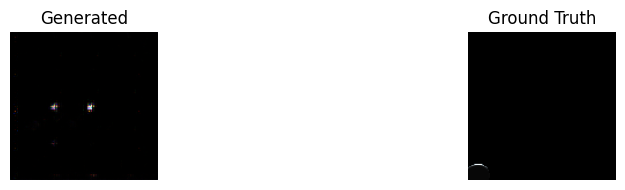

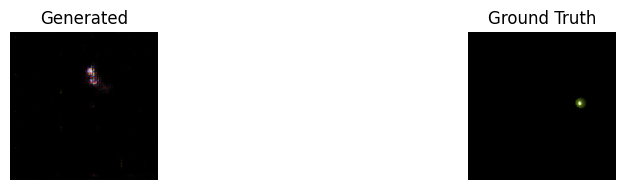

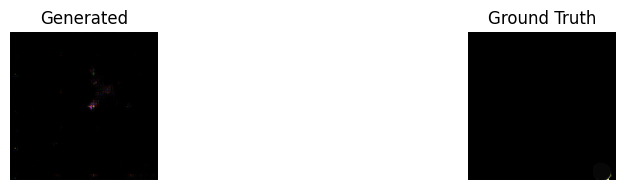

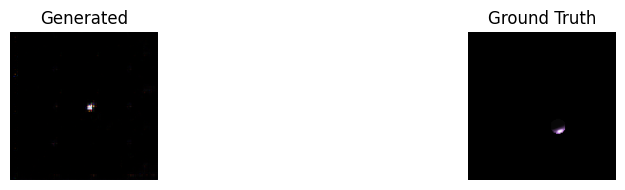

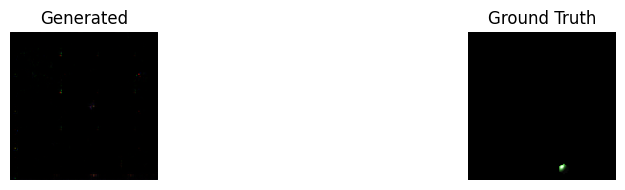

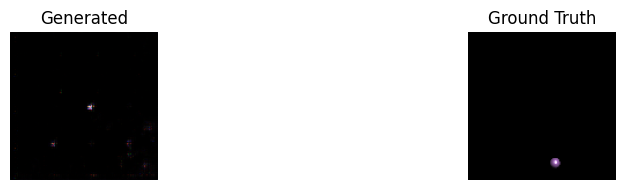

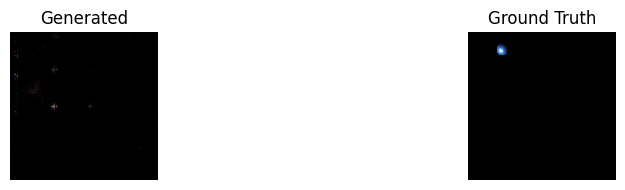

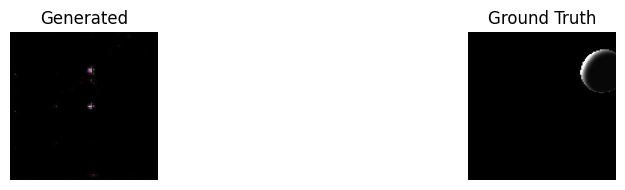

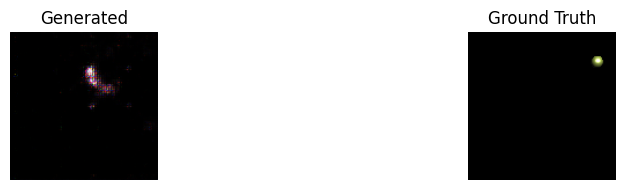

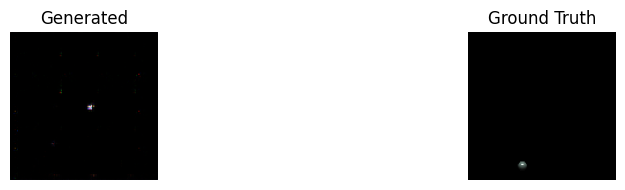

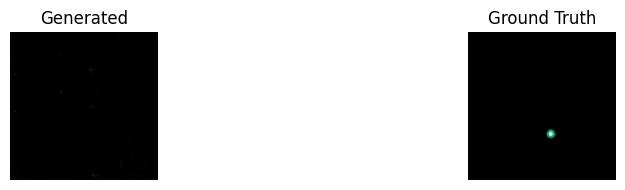

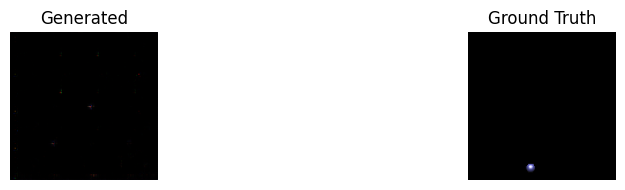

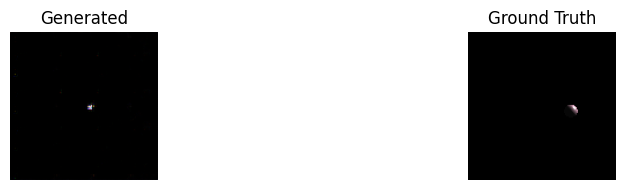

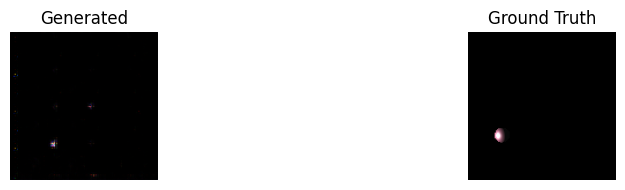

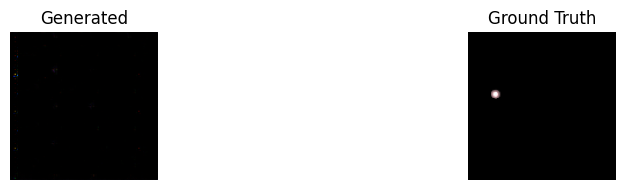

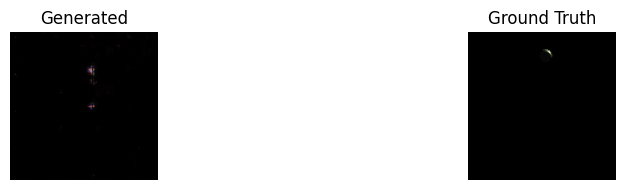

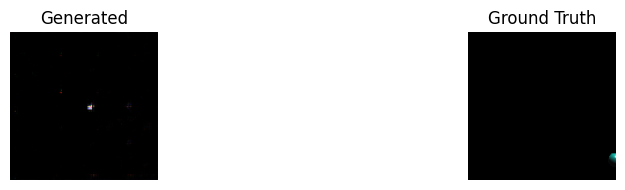

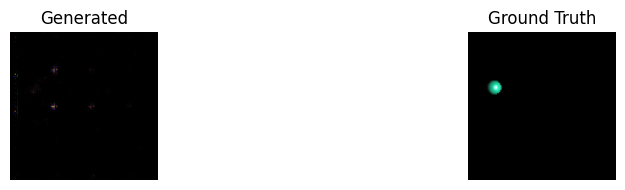

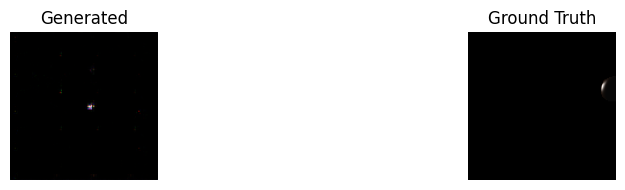

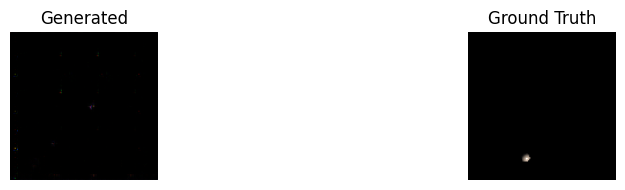

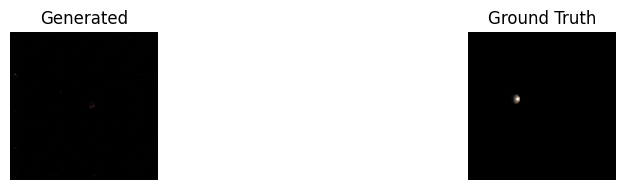

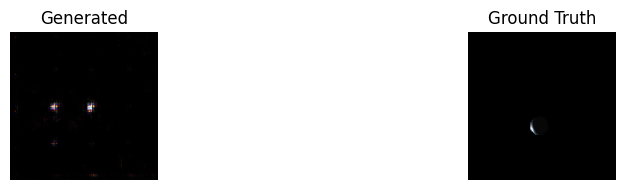

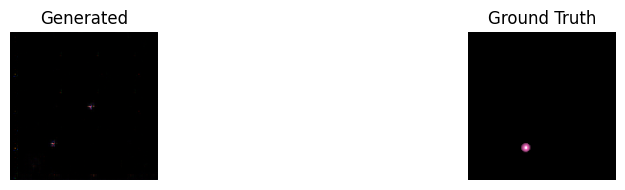

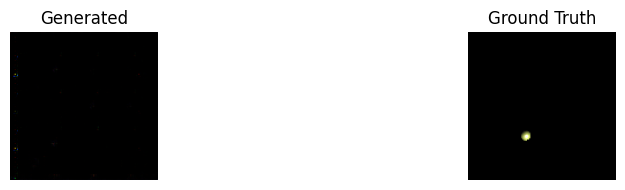

In [71]:
n = 10
i = 0
generator.eval()
for input_image, target_image in test_loader:
  if(i>n):
    break

  input_image, target_image = input_image.to(device), target_image.to(device)


  with torch.no_grad():
    generated = generator(input_image)

  compare_images(generated, target_image)
  i+=1

Metrics


In [ ]:
!pip install flip_evaluator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.2/415.2 kB 31.9 MB/s eta 0:00:00


In [ ]:
!pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
import cv2
import flip_evaluator as flip
import lpips
import torch
import torch.nn as nn
from skimage.metrics import hausdorff_distance
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import DataLoader
import numpy as np

def LPIPS(original, generated, device):
    lpips_loss_fn = lpips.LPIPS(net="vgg").to(device)
    device = next(lpips_loss_fn.parameters()).device
    #original = original.unsqueeze(0).to(device)
    #generated = generated.unsqueeze(0).to(device)
    lpips_val = lpips_loss_fn(original, generated)

    return lpips_val.mean().item()


def SSIM(original, generated):
    original_np = original.cpu().numpy()
    generated_np = generated.cpu().numpy()
    batch_scores = []

    for i in range(original_np.shape[0]):
        score, _ = ssim(
            original_np[i],
            generated_np[i], channel_axis=0, data_range=1.0, full=True
        )
        batch_scores.append(score)

    return torch.tensor(batch_scores).mean()


def FLIP(original, generated):
    original_np = original.detach().cpu().numpy()
    generated_np = generated.detach().cpu().numpy()
    batch_scores = []

    for i in range(original_np.shape[0]):
        _, mean_flip_error, _ = flip.evaluate(original_np[i], generated_np[i], "LDR")
        batch_scores.append(mean_flip_error)

    return torch.tensor(batch_scores).mean()



def hausdorff_distance_metric(original, generated):
    if torch.is_tensor(original):
        original = original.cpu().numpy()
    if torch.is_tensor(generated):
        generated = generated.cpu().numpy()

    if len(original.shape) == 3 and original.shape[0] in [1, 3, 4]:
        original = original.transpose(1, 2, 0)
    if len(generated.shape) == 3 and generated.shape[0] in [1, 3, 4]:
        generated = generated.transpose(1, 2, 0)

    if original.max() <= 1.0:
        original = (original * 255).astype("uint8")
    else:
        original = original.astype("uint8")

    if generated.max() <= 1.0:
        generated = (generated * 255).astype("uint8")
    else:
        generated = generated.astype("uint8")

    if len(original.shape) == 3 and original.shape[2] == 3:
        original = cv2.cvtColor(original, cv2.COLOR_RGB2GRAY)
    elif len(original.shape) == 3 and original.shape[2] == 1:
        original = original.squeeze(2)

    if len(generated.shape) == 3 and generated.shape[2] == 3:
        generated = cv2.cvtColor(generated, cv2.COLOR_RGB2GRAY)
    elif len(generated.shape) == 3 and generated.shape[2] == 1:
        generated = generated.squeeze(2)
    t_lower = 50
    t_upper = 150
    edge_original = cv2.Canny(original, t_lower, t_upper)
    cv2.imshow("Edge Original", edge_original)
    cv2.waitKey(1)
    edge_generated = cv2.Canny(generated, t_lower, t_upper)
    cv2.imshow("Edge Generated", edge_generated)
    cv2.waitKey(1)
    return hausdorff_distance(edge_original, edge_generated)


def evaluate_SSIM(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = (
                modified_img.to(device),
                original_img.to(device),
            )
            generated_img = model(modified_img)

            score = SSIM(original_img, generated_img)
            total_score += score.item()
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average SSIM: {average_score:.4f}")
    return average_score


def evaluate_LPIPS(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = (
                modified_img.to(device),
                original_img.to(device),
            )
            generated_img = model(modified_img)
            score = LPIPS(original_img, generated_img, device)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average LPIPS: {average_score:.4f}")
    return average_score


def evaluete_FLIP(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_score = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = (
                modified_img.to(device),
                original_img.to(device),
            )
            generated_img = model(modified_img)
            score = FLIP(original_img, generated_img)
            total_score += score
            num_batches += 1
    average_score = total_score / num_batches
    print(f"Average FLIP: {average_score:.4f}")
    return average_score


def evaluate_hausdorff_distance(model: nn.Module, data: DataLoader, device: str):
    model.eval()
    total_distance = 0
    num_batches = 0
    with torch.no_grad():
        for modified_img, original_img in data:
            modified_img, original_img = (
                modified_img.to(device),
                original_img.to(device),
            )
            generated_img = model(modified_img)
            distance = hausdorff_distance_metric(original_img, generated_img)
            total_distance += distance
            num_batches += 1
    average_distance = total_distance / num_batches
    print(f"Average Hausdorff Distance: {average_distance:.4f}")
    return average_distance

In [ ]:
avg_lpips = evaluate_LPIPS(generator, test_loader, device)
print(f"Avarage LPIPS: {avg_lpips}")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 221MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-p

In [ ]:
avg_hausdorff = evaluate_hausdorff_distance(generator, test_loader, device)
print(f"Avarage hausdorff: {avg_hausdorff}")

Average Hausdorff Distance: inf
Avarage hausdorff: inf


In [ ]:
avg_ssim = evaluate_SSIM(generator, test_loader, device)
print(f"Avarager SSIM: {avg_ssim}")

Average SSIM: 0.0301
Avarager SSIM: 0.030144104194876394


In [ ]:
avg_flip = evaluete_FLIP(generator, test_loader, device)
print(f"Avarager FLIP: {avg_flip}")

Average FLIP: 0.0902
Avarager FLIP: 0.0901649072766304
